# Trabalho de séries temporais - Pipeline completa para uma serie temporal não estacionária

In [ ]:
import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
import kagglehub
import os
import pandas as pd
import numpy as np
from itertools import product
from matplotlib import pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
warnings.filterwarnings("ignore")



## Carregando a base

In [ ]:
path_brazil = kagglehub.dataset_download("azminetoushikwasi/brazil-all-international-matches-19142023")

print("Path to dataset files:", path_brazil)

Path to dataset files: C:\Users\miguelaraujo-ieg\.cache\kagglehub\datasets\azminetoushikwasi\brazil-all-international-matches-19142023\versions\4


In [ ]:
df_brazil = pd.read_csv(os.path.join(path_brazil, "brazil.csv"))

In [5]:
df_brazil

,Date,Match,Result,Score,Competition
0,20 Sep 1914,Argentina v Brazil,L,3-0,International Friendly
1,27 Sep 1914,Argentina v Brazil,W,0-1,Copa Julio Roca
2,08 Jul 1916,Chile v Brazil,D,1-1,Copa America
3,10 Jul 1916,Argentina v Brazil,D,1-1,Copa America
4,12 Jul 1916,Uruguay v Brazil,L,2-1,Copa America
...,...,...,...,...,...
1029,24 Nov 2022,Brazil v Serbia,W,2-0,FIFA World Cup
1030,28 Nov 2022,Brazil v Switzerland,W,1-0,FIFA World Cup
1031,02 Dec 2022,Cameroon v Brazil,L,1-0,FIFA World Cup
1032,05 Dec 2022,Brazil v Korea Republic,W,4-1,FIFA World Cup


## Fazendo limpeza da base

In [6]:
df_brazil = df_brazil.dropna(subset=['Date', 'Result'])
df_brazil

,Date,Match,Result,Score,Competition
0,20 Sep 1914,Argentina v Brazil,L,3-0,International Friendly
1,27 Sep 1914,Argentina v Brazil,W,0-1,Copa Julio Roca
2,08 Jul 1916,Chile v Brazil,D,1-1,Copa America
3,10 Jul 1916,Argentina v Brazil,D,1-1,Copa America
4,12 Jul 1916,Uruguay v Brazil,L,2-1,Copa America
...,...,...,...,...,...
1029,24 Nov 2022,Brazil v Serbia,W,2-0,FIFA World Cup
1030,28 Nov 2022,Brazil v Switzerland,W,1-0,FIFA World Cup
1031,02 Dec 2022,Cameroon v Brazil,L,1-0,FIFA World Cup
1032,05 Dec 2022,Brazil v Korea Republic,W,4-1,FIFA World Cup


#### Colunas específicas

In [7]:
df_brazil = df_brazil[['Date', 'Result']]
df_brazil

,Date,Result
0,20 Sep 1914,L
1,27 Sep 1914,W
2,08 Jul 1916,D
3,10 Jul 1916,D
4,12 Jul 1916,L
...,...,...
1029,24 Nov 2022,W
1030,28 Nov 2022,W
1031,02 Dec 2022,L
1032,05 Dec 2022,W


#### Transformando coluna de data em formato amigável

In [8]:
df_brazil['Date'] = pd.to_datetime(df_brazil['Date'], format='%d %b %Y')
df_brazil

,Date,Result
0,1914-09-20,L
1,1914-09-27,W
2,1916-07-08,D
3,1916-07-10,D
4,1916-07-12,L
...,...,...
1029,2022-11-24,W
1030,2022-11-28,W
1031,2022-12-02,L
1032,2022-12-05,W


#### Criando regra de negócio da serie temporal

In [9]:
df_brazil['win'] = (df_brazil['Result'] == 'W').astype(int)

df_brazil['year'] = df_brazil['Date'].dt.year

sr_brazil = df_brazil.groupby('year')['win'].sum()
sr_brazil

year
1914     1
1916     2
1917     1
1919     3
1920     1
        ..
2018    13
2019     9
2020     4
2021    12
2022    10
Name: win, Length: 97, dtype: int64

#### Plot das series

In [ ]:
def plot_serie(serie):
    fig, ax = plt.subplots()
    ax.plot(serie)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)    
    plt.tight_layout()
    plt.show()

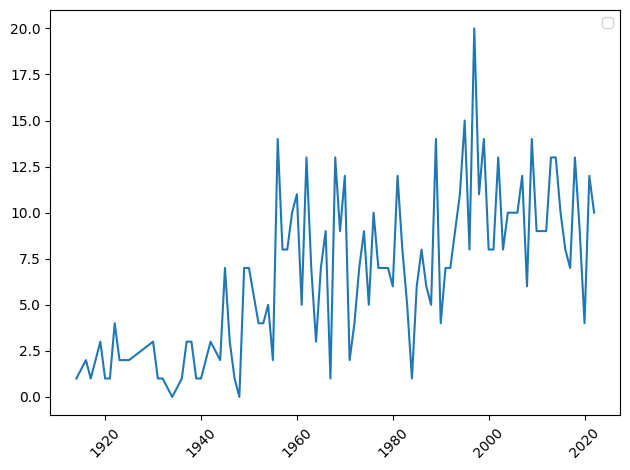

In [11]:
plot_serie(sr_brazil)  

## Fazendo os testes na série - ACF e PACF, Sazonalidade, ADF e KPSS

#### Fazendo metodo de autocorrelação e autocorrelação parcial

In [ ]:
def plot_acf_pacf(serie):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    plot_acf(serie, ax=axes[0])
    plot_pacf(serie, ax=axes[1])
    plt.show()

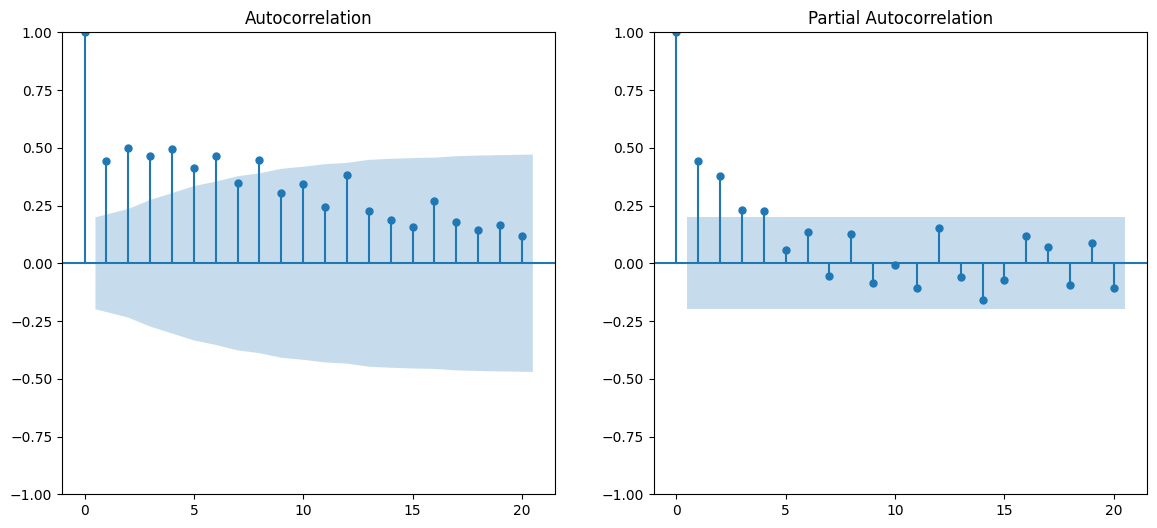

In [13]:
plot_acf_pacf(sr_brazil)

#### Fazendo teste de força sazonal para verificar a sazonalidade da série

In [ ]:
valores_m = range(2, 31)

forcas = []

for m in valores_m:
    try:
        stl = STL(sr_brazil, period=m, robust=True).fit()

        forca = 1 - (
            np.var(stl.resid) /
            np.var(stl.seasonal + stl.resid)
        )

        forcas.append(forca)

    except Exception as e:
        print(f'Erro em m = {m}: {e}')

media_forca = np.mean(forcas)
maior_forca = max(forcas)

print('\n-----------------------------------')
print(f'Média da força da sazonalidade: {media_forca:.5f}')
print(f'Maior força da sazonalidade: {maior_forca:.5f} no periodo {valores_m[forcas.index(maior_forca)]}')
print('-----------------------------------')


-----------------------------------
Média da força da sazonalidade: 0.15918
Maior força da sazonalidade: 0.46058 no periodo 29
-----------------------------------


### A SÉRIE NÃO É SAZONAL

#### Fazendo os metodos estatísticos de estacionariedade

In [ ]:
def teste_adf(serie, nome):
    resultado = adfuller(serie, autolag='AIC')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor < 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\nTeste ADF — {nome}')
    print(f'  Estatística ADF: {resultado[0]:.4f}')
    print(f'  p-value:         {p_valor:.6f}')
    print(f'  Lags usados:     {resultado[2]}')
    print(f'  Observações:     {resultado[3]}')
    for key, val in resultado[4].items():
        print(f' Valor crítico {key}: {val:.4f}')
    print(f' Conclusão ADF: {conclusao}')
    return p_valor

def teste_kpss(serie, nome):
    resultado = kpss(serie, regression='c', nlags='auto')
    p_valor = resultado[1]
    conclusao = 'ESTACIONÁRIA' if p_valor >= 0.05 else 'NÃO ESTACIONÁRIA'
    
    print(f'\nTeste KPSS — {nome}')
    print(f'  Estatística KPSS: {resultado[0]:.4f}')
    print(f'  p-value:          {p_valor:.4f}')
    print(f'  Lags usados:      {resultado[2]}')
    for key, val in resultado[3].items():
        print(f'  Valor crítico {key}: {val:.4f}')
    print(f'  Conclusão KPSS: {conclusao}')
    return p_valor

def analise_estacionariedade(serie, nome):
    p_adf = teste_adf(serie, nome)
    p_kpss = teste_kpss(serie, nome)
    
    print(f'\nConclusão combinada para "{nome}"')
    if p_adf < 0.05 and p_kpss >= 0.05:
        print('Ambos os testes concordam: ESTACIONÁRIA')
    elif p_adf >= 0.05 and p_kpss < 0.05:
        print(' Ambos os testes concordam: NÃO ESTACIONÁRIA')
    print('=' * 50)

In [16]:
analise_estacionariedade(sr_brazil, 'Série de vitorias do Brasil')


=== Teste ADF — Série de vitorias do Brasil ===
  Estatística ADF: -2.0557
  p-value:         0.262685
  Lags usados:     3
  Observações:     93
  Valor crítico 1%: -3.5027
  Valor crítico 5%: -2.8932
  Valor crítico 10%: -2.5836
  → Conclusão ADF: NÃO ESTACIONÁRIA

=== Teste KPSS — Série de vitorias do Brasil ===
  Estatística KPSS: 1.3068
  p-value:          0.0100
  Lags usados:      5
  Valor crítico 10%: 0.3470
  Valor crítico 5%: 0.4630
  Valor crítico 2.5%: 0.5740
  Valor crítico 1%: 0.7390
  → Conclusão KPSS: NÃO ESTACIONÁRIA

--- Conclusão combinada para "Série de vitorias do Brasil" ---
 Ambos os testes concordam: NÃO ESTACIONÁRIA


C:\Users\miguelaraujo-ieg\AppData\Local\Temp\ipykernel_21420\3872084422.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(serie, regression='c', nlags='auto')


### A SÉRIE É NÃO ESTACIONÁRIA

## Fazendo modelo SARIMA

In [ ]:
# treino teste
h = 10
ytrain = sr_brazil.iloc[:-h]
ytest = sr_brazil.iloc[-h:]


def tentar_sarima(order, seasonal_order, y):
    try:
        model = SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False, maxiter=100)

        return res

    except Exception:
        return None

#### Utilizando seasonal_order = (0,0,0,0) pois a série é NÃO SAZONAL

In [ ]:
p_range = range(0, 4)
d_range = range(0, 3)
q_range = range(0, 4)

best_aic = float('inf')
best_bic = None
best_order = None
best_model = None

seasonal_order = (0,0,0,0)
for order in product(p_range, d_range, q_range):

    try:

        model = SARIMAX(
            ytrain,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False)

        aic = res.aic
        bic = res.bic

        print(f'ARIMA{order} | AIC={aic:.2f} | BIC={bic:.2f}')

        if aic < best_aic:
            best_bic = bic
            best_aic = aic
            best_order = order
            best_model = res

    except Exception as e:
        print(f'ERRO EM {order}: {e}')
        continue

print('\n=================================')
print(f'Melhor ordem: {best_order}')
print(f'Melhor AIC: {best_aic:.2f}')
print(f'Mlehor BIC: {best_bic:.2f}')
print('=================================')

ARIMA(0, 0, 0) | AIC=600.08 | BIC=602.54
ARIMA(0, 0, 1) | AIC=554.64 | BIC=559.52
ARIMA(0, 0, 2) | AIC=524.33 | BIC=531.62
ARIMA(0, 0, 3) | AIC=506.88 | BIC=516.55
ARIMA(0, 1, 0) | AIC=499.88 | BIC=502.33
ARIMA(0, 1, 1) | AIC=445.91 | BIC=450.77
ARIMA(0, 1, 2) | AIC=441.59 | BIC=448.85
ARIMA(0, 1, 3) | AIC=439.18 | BIC=448.80
ARIMA(0, 2, 0) | AIC=591.96 | BIC=594.39
ARIMA(0, 2, 1) | AIC=495.29 | BIC=500.13
ARIMA(0, 2, 2) | AIC=442.58 | BIC=449.80
ARIMA(0, 2, 3) | AIC=438.75 | BIC=448.33
ARIMA(1, 0, 0) | AIC=499.96 | BIC=504.87
ARIMA(1, 0, 1) | AIC=452.12 | BIC=459.45
ARIMA(1, 0, 2) | AIC=448.43 | BIC=458.15
ARIMA(1, 0, 3) | AIC=445.95 | BIC=458.04
ARIMA(1, 1, 0) | AIC=466.08 | BIC=470.97
ARIMA(1, 1, 1) | AIC=445.75 | BIC=453.04
ARIMA(1, 1, 2) | AIC=441.97 | BIC=451.65
ARIMA(1, 1, 3) | AIC=439.64 | BIC=451.67
ARIMA(1, 2, 0) | AIC=530.15 | BIC=535.02
ARIMA(1, 2, 1) | AIC=462.70 | BIC=469.95
ARIMA(1, 2, 2) | AIC=442.63 | BIC=452.25
ARIMA(1, 2, 3) | AIC=438.09 | BIC=450.06
ARIMA(2, 0, 0) |

### Melhor modelo SARIMA (1,2,3) x (0,0,0,0)
Os parâmetros significam:

- p = 1 → parte autoregressiva (AR)
- d = 2 → diferenciação
- q = 3 → média móvel (MA)

Como o modelo sazonal ficou (0,0,0,0), então ele é efetivamente um ARIMA puro, sem sazonalidade.

## Analisando a normalidade dos residuos

### Metodo para diagnosticar os residuos com acf e ljung box

In [ ]:
def diagnostico_residuos(modelo, lags=30):

    residuos = modelo.resid

    plt.figure(figsize=(10,5))
    plot_acf(residuos, lags=lags)
    plt.title('ACF dos Resíduos')
    plt.show()

    lb = acorr_ljungbox(
        residuos,
        lags=[lags],
        return_df=True
    )

    print('\n===================================')
    print('Teste de Ljung-Box')
    print('===================================')
    print(lb)

    pvalor = lb['lb_pvalue'].values[0]

    if pvalor > 0.05:
        print('Resíduos parecem ruído branco')
        print(f'p-value = {pvalor:.5f}')
    else:
        print('Resíduos NÃO parecem ruído branco')
        print(f'p-value = {pvalor:.5f}')


### Modelo com os melhores parametros

In [29]:
melhor_modelo = SARIMAX(
            ytrain,
            order=best_order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

melhor_modelo_treinado = melhor_modelo.fit()

<Figure size 1000x500 with 0 Axes>

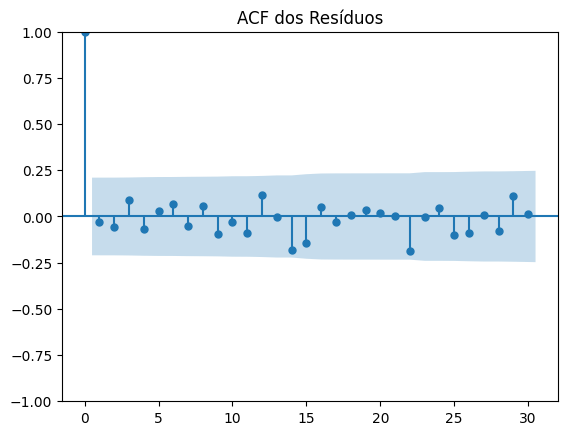


Teste de Ljung-Box
      lb_stat  lb_pvalue
30  21.229462   0.880576

-----------------------------------
Resíduos parecem ruído branco
p-value = 0.88058
-----------------------------------


In [30]:
diagnostico_residuos(melhor_modelo_treinado)

### Calculando as métricas de avaliação da serie temporal com roling forecast

In [ ]:
def rolling_forecast_modelo(
    modelo_fitado,
    ytrain,
    ytest
):
    order = modelo_fitado.model.order
    seasonal_order = modelo_fitado.model.seasonal_order

    print(f'\nUsando ARIMA{order} x {seasonal_order}')

    history = list(ytrain)

    previsoes = []

    for t in range(len(ytest)):

        model = SARIMAX(
            history,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False)

        yhat = res.forecast()[0]

        previsoes.append(yhat)

        history.append(ytest.iloc[t])

    ypred = pd.Series(
        previsoes,
        index=ytest.index
    )

    mae = mean_absolute_error(ytest, ypred)

    mse = mean_squared_error(ytest, ypred)

    rmse = np.sqrt(mse)

    mape = mean_absolute_percentage_error(ytest, ypred) * 100

    r2 = r2_score(ytest, ypred)

    print('\n===================================')
    print('MÉTRICAS ROLLING FORECAST')
    print('===================================')

    print(f'MAE  : {mae:.5f}')
    print(f'MSE  : {mse:.5f}')
    print(f'RMSE : {rmse:.5f}')
    print(f'MAPE : {mape:.2f}%')
    print(f'R²   : {r2:.5f}')

    print('===================================')
    plt.figure(figsize=(14,6))

    plt.plot(ytest.index, ytest, label='Real')

    plt.plot(ytest.index, ypred, label='Previsão')

    plt.title(f'Rolling Forecast ARIMA{order}')

    plt.legend()

    plt.grid(True)

    plt.show()

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'predicoes': ypred
    }


Usando ARIMA(1, 2, 3) x (0, 0, 0, 0)

MÉTRICAS ROLLING FORECAST
MAE  : 2.86228
MSE  : 10.89421
RMSE : 3.30064
MAPE : 39.51%
R²   : -0.34663


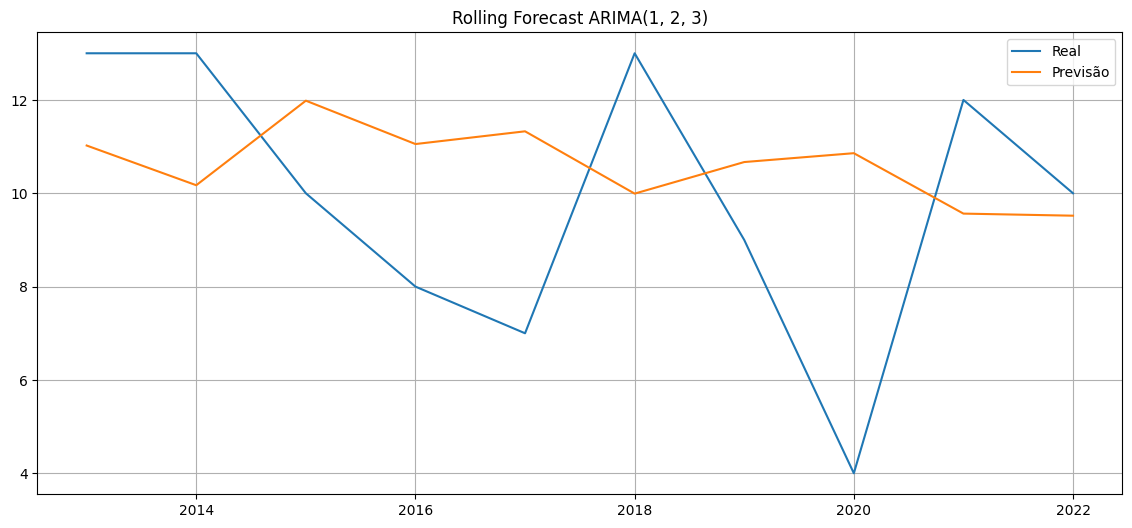

{'MAE': 2.8622826646991464,
 'MSE': 10.894209405767116,
 'RMSE': np.float64(3.300637727132003),
 'MAPE': 39.50684088853652,
 'R2': -0.34662662617640505,
 'predicoes': year
 2013    11.023359
 2014    10.172487
 2015    11.984425
 2016    11.054972
 2017    11.327792
 2018     9.992783
 2019    10.669267
 2020    10.859062
 2021     9.564358
 2022     9.519704
 dtype: float64}

In [33]:
rolling_forecast_modelo(melhor_modelo_treinado, ytrain, ytest)

In [ ]:
def calcular_quatro_erros(serie_real, serie_previsao):
 
    previsao_limpa = serie_previsao.dropna()
    real_alinhado = serie_real[previsao_limpa.index]
   
    if len(real_alinhado) == 0:
        return np.nan, np.nan, np.nan, np.nan
       
    mae = mean_absolute_error(real_alinhado, previsao_limpa)
    mse = mean_squared_error(real_alinhado, previsao_limpa)
    rmse = np.sqrt(mse)
   
    mask_mape = (real_alinhado != 0)
    if mask_mape.sum() > 0:
        mape = mean_absolute_percentage_error(real_alinhado[mask_mape], previsao_limpa[mask_mape])
    else:
        mape = np.nan
       
    return mae, mse, rmse, mape
 
 
def encontrar_melhor_basemodel(serie):
    tamanho_serie = len(serie)
    resultados_lista = []
   
    if tamanho_serie < 4:
        raise ValueError("A série temporal é demasiado curta para testar todos os modelos.")
 
    previsao_hist = pd.Series(serie.mean(), index=serie.index).shift(1)
    mae, mse, rmse, mape = calcular_quatro_erros(serie, previsao_hist)
    resultados_lista.append({
        'Modelo': 'Média Histórica', 'Parâmetro': 'Global',
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape
    })
 

    previsao_acum = serie.expanding().mean().shift(1)
    mae, mse, rmse, mape = calcular_quatro_erros(serie, previsao_acum)
    resultados_lista.append({
        'Modelo': 'Média Acumulada', 'Parâmetro': 'Histórico Total',
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape
    })

    for janela in range(1, tamanho_serie):
        previsao_sma = serie.rolling(window=janela).mean().shift(1)
        mae, mse, rmse, mape = calcular_quatro_erros(serie, previsao_sma)
        if not np.isnan(mae):
            resultados_lista.append({
                'Modelo': 'Média Móvel Simples (SMA)', 'Parâmetro': f'Janela: {janela}',
                'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape
            })
 
    alphas = np.round(np.arange(0.1, 1.0, 0.1), 2)
    for alpha in alphas:
        previsao_ema = serie.ewm(alpha=alpha, adjust=False).mean().shift(1)
        mae, mse, rmse, mape = calcular_quatro_erros(serie, previsao_ema)
        if not np.isnan(mae):
            resultados_lista.append({
                'Modelo': 'Média Móvel Exponencial (EMA)', 'Parâmetro': f'Alpha: {alpha}',
                'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape
            })
 
   
    for janela in range(1, tamanho_serie - 1):
        previsao_delta = (serie + (serie - serie.shift(janela)) / janela).shift(1)
        mae, mse, rmse, mape = calcular_quatro_erros(serie, previsao_delta)
        if not np.isnan(mae):
            resultados_lista.append({
                'Modelo': 'Delta (Diferenciação)', 'Parâmetro': f'Janela: {janela}',
                'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape
            })
 
    serie_denominador = serie.replace(0, np.nan) 
    for janela in range(1, tamanho_serie - 1):
        passado = serie_denominador.shift(janela)
        taxa = (serie - passado) / passado
        previsao_taxa = (serie * (1 + taxa)).shift(1)
       
        
        previsao_taxa = previsao_taxa.replace([np.inf, -np.inf], np.nan)
       
        mae, mse, rmse, mape = calcular_quatro_erros(serie, previsao_taxa)
        if not np.isnan(mae):
            resultados_lista.append({
                'Modelo': 'Taxa de Variação', 'Parâmetro': f'Janela: {janela}',
                'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape
            })
 
    
    for s in range(1, (tamanho_serie // 2) + 1):
        previsao_szn = serie.shift(s)
        mae, mse, rmse, mape = calcular_quatro_erros(serie, previsao_szn)
        if not np.isnan(mae):
            resultados_lista.append({
                'Modelo': 'Sazonal (Seasonal Naive)', 'Parâmetro': f'Sazonalidade: {s}',
                'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape
            })
 
    df_ranking = pd.DataFrame(resultados_lista)
   
   
    df_ranking = df_ranking.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
   
    melhor_modelo = df_ranking.iloc[0]
   
    print("-" * 60)
    print("O MELHOR BASEMODEL ENCONTRADO:")
    print(f"Modelo:    {melhor_modelo['Modelo']}")
    print(f"Parâmetro: {melhor_modelo['Parâmetro']}")
    print(f"RMSE:      {melhor_modelo['RMSE']:.4f}")
    print(f"MAE:       {melhor_modelo['MAE']:.4f}")
    print(f"MAPE:      {melhor_modelo['MAPE'] * 100:.2f}%")
    print("-" * 60)
   
    return df_ranking
 
ranking_completo = encontrar_melhor_basemodel(sr_brazil)
   
print("\nTOP 5 CONFIGURAÇÕES:")
print(ranking_completo.head(5))
 

------------------------------------------------------------
🏆 O MELHOR BASEMODEL ENCONTRADO:
Modelo:    Delta (Diferenciação)
Parâmetro: Janela: 95
RMSE:      2.1158
MAE:       2.1158
MAPE:      21.16%
------------------------------------------------------------

TOP 5 CONFIGURAÇÕES:
                          Modelo   Parâmetro       MAE        MSE      RMSE  \
0          Delta (Diferenciação)  Janela: 95  2.115789   4.476565  2.115789   
1      Média Móvel Simples (SMA)  Janela: 96  3.166667  10.027778  3.166667   
2  Média Móvel Exponencial (EMA)  Alpha: 0.2  2.409135  10.833902  3.291489   
3  Média Móvel Exponencial (EMA)  Alpha: 0.3  2.483509  11.188110  3.344863   
4      Média Móvel Simples (SMA)   Janela: 6  2.510989  11.226190  3.350551   

       MAPE  
0  0.211579  
1  0.316667  
2  0.540470  
3  0.567604  
4  0.545665  


### Comparação do melhor base model com o melhor SARIMA

In [ ]:
def comparar_sarima_vs_basemodel(
    modelo_sarima,
    ytrain,
    ytest,
    serie_completa
):

    resultado_sarima = rolling_forecast_modelo(
        modelo_sarima,
        ytrain,
        ytest
    )

    rmse_sarima = resultado_sarima['RMSE']

    ranking_basemodel = encontrar_melhor_basemodel(
        serie_completa
    )

    melhor_basemodel = ranking_basemodel.iloc[0]

    rmse_base = melhor_basemodel['RMSE']


  
    print('=' * 60)
    print('COMPARAÇÃO FINAL')
    print('=' * 60)

    print(f'SARIMA RMSE:     {rmse_sarima:.5f}')
    print(f'BASEMODEL RMSE:  {rmse_base:.5f}')



    
    if rmse_sarima < rmse_base:

        print(' SARIMA É MELHOR')
        print('\nModelo vencedor:')

        print(
            f'ARIMA{modelo_sarima.model.order} '
            f'x {modelo_sarima.model.seasonal_order}'
        )

        vencedor = {
            'tipo': 'SARIMA',
            'rmse': rmse_sarima,
            'modelo': f'ARIMA{modelo_sarima.model.order}'
        }

    else:

        print('BASEMODEL É MELHOR')

        print('\nMelhor basemodel:')

        print(f"Modelo:    {melhor_basemodel['Modelo']}")
        print(f"Parâmetro: {melhor_basemodel['Parâmetro']}")

        vencedor = {
            'tipo': 'BASEMODEL',
            'rmse': rmse_base,
            'modelo': melhor_basemodel['Modelo'],
            'parametro': melhor_basemodel['Parâmetro']
        }

    print('=' * 60)

    resumo = pd.DataFrame([
        {
            'Modelo': 'SARIMA',
            'RMSE': rmse_sarima
        },
        {
            'Modelo': melhor_basemodel['Modelo'],
            'RMSE': rmse_base
        }
    ]).sort_values(by='RMSE')

    return {
        'vencedor': vencedor,
        'resumo': resumo,
        'ranking_basemodel': ranking_basemodel,
        'resultado_sarima': resultado_sarima
    }


Usando ARIMA(1, 2, 3) x (0, 0, 0, 0)

MÉTRICAS ROLLING FORECAST
MAE  : 2.86228
MSE  : 10.89421
RMSE : 3.30064
MAPE : 39.51%
R²   : -0.34663


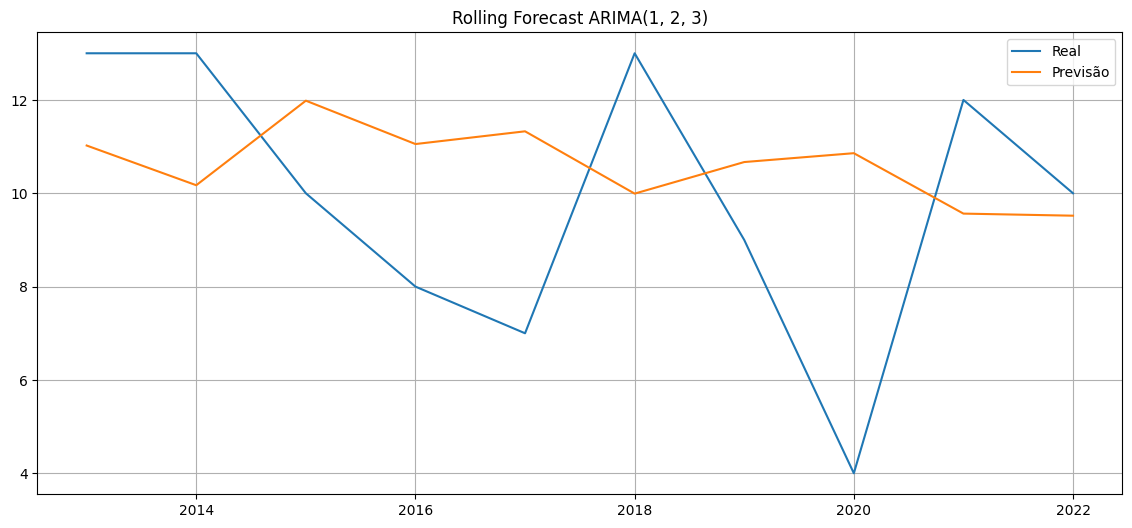

------------------------------------------------------------
🏆 O MELHOR BASEMODEL ENCONTRADO:
Modelo:    Delta (Diferenciação)
Parâmetro: Janela: 95
RMSE:      2.1158
MAE:       2.1158
MAPE:      21.16%
------------------------------------------------------------


COMPARAÇÃO FINAL
SARIMA RMSE:     3.30064
BASEMODEL RMSE:  2.11579


🏆 BASEMODEL É MELHOR

Melhor basemodel:
Modelo:    Delta (Diferenciação)
Parâmetro: Janela: 95
                  Modelo      RMSE
1  Delta (Diferenciação)  2.115789
0                 SARIMA  3.300638


In [38]:
resultado = comparar_sarima_vs_basemodel(
    melhor_modelo_treinado,
    ytrain,
    ytest,
    sr_brazil
)

print(resultado['resumo'])